In [2]:
import numpy as np
import pandas as pd
import locan as lc
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.miscellaneous as mi
import src.figure as fi
import src.blinking as bl
import src.emissions as em

%load_ext autoreload
%autoreload 2

In [3]:
path = r"C:\Users\ebert\OneDrive - Universität Würzburg\origami\3nm-Origami_TimeTrace\3nm-TT-1msBIN-1.dat"

In [4]:
data = pd.read_csv(path, sep='\t', header=1)
data['Intens.[Cnts]'] = data['Intens.[Cnts]'].apply(lambda x: 0 if x < 7 else x)

In [5]:
emissions = em.Emissions()
emissions.event_time_series = pd.Series(data['Intens.[Cnts]'].values, data['Time[s]'])

In [32]:
blinks = bl.Blinking(emissions, memory=20)

In [33]:
blinks.off_periods

array([    23,     21,     36,     22,     26,     28,     38,     38,
           56,     24,     25,     25,     23,     26,     28,     24,
           29,     22,     24,     32,     23,     29,     23,     25,
           30,     25,     31,     24,     21,     25,     67,     36,
           24,     24,    148,     46,     83,     72,    100,     75,
           79,     81,     45,     36,     41,     50,     57,     80,
           35,     26,     24,     63,    119,     22,     34,     31,
           26,     36,     47,     32,     28,     30,     33,     30,
           27,     30,     72,     21,     24,     32,     23,     23,
           32,     24,    120,     34,     24,     21,     24,     31,
           29,     78,     35,     52,     33,  52570,   2109,  27987,
          224,   6059,   6792, 139429,    163,  35638])

array([[<Axes: title={'center': 'OFF periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

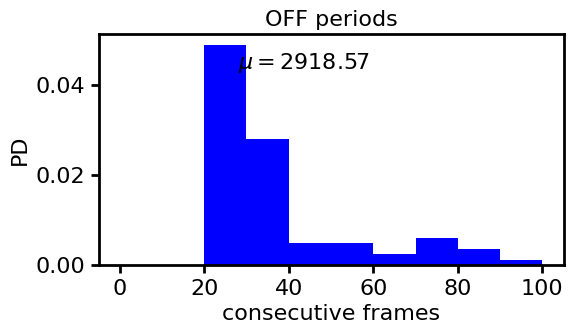

In [34]:
blinks.plot(mode='off_histogram', range=[0, 100])

In [35]:
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time='1ms',
)

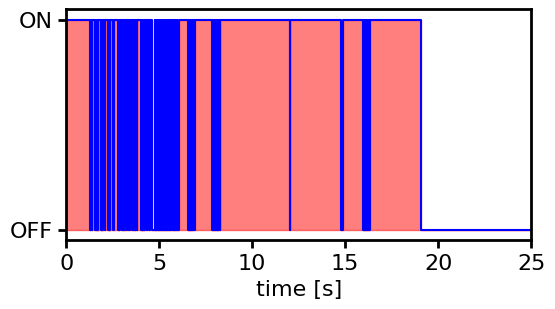

In [36]:
ax = bl.plot_off_statistics(on_off_times_analytic, on_off_values_analytic, xlim=[0, 25])
ax[0, 0].fill_between(on_off_times_analytic, on_off_values_analytic, color='red', alpha=0.5)

array([[<Axes: title={'center': 'ON periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

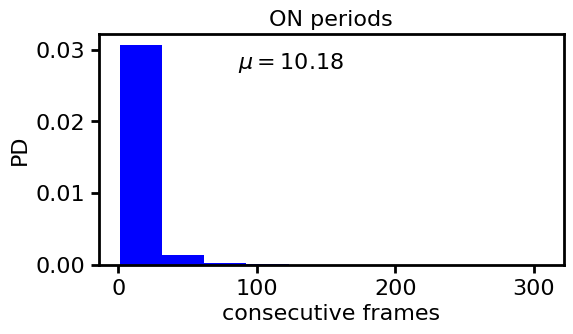

In [9]:
blinks.plot(mode='on_histogram')

(0.0, 100.0)

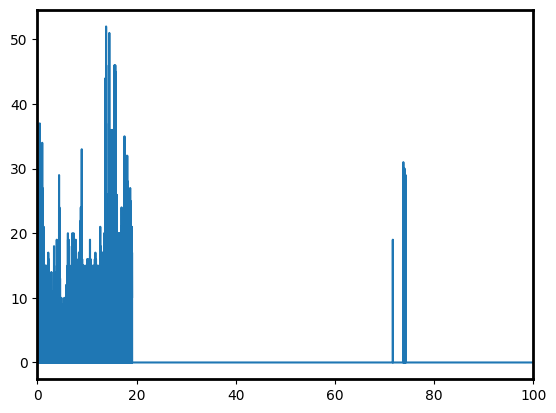

In [10]:
plt.plot(data['Time[s]'], data['Intens.[Cnts]'])
plt.xlim(0, 100)